# Imports

In [36]:
import os
import sys

In [37]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [39]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

# Data

In [40]:
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}
HD143006 = {'inc': 18.6, 'pa': 169, 'dra':-5.9e-3, 'ddec':21.7e-3, 'rout': 0.518*3, 'disk_name': 'HD143006'}

In [41]:
data = AS209

dir = "/Users/mariajmelladot/Desktop/Frank2D/data/uvtables/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

# Huang 2018 
inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

In [42]:
# Frank Parameters
N = 300
# load data
file = np.load(data_file)

u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j

# F2D

### Run

In [43]:
geom = Geometry(inc, pa, dra, ddec)
frank2d = Frank2D(N, rout, geom)

In [44]:
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights}

In [45]:
frank2d.process_vis(uvtable)

Setting gridded data...


Setting GP Kernel Wendland...
Creating sparse linear system...
--> time kernel = 1.07  min |  63.99 seconds
--> time = 1.09  min |  65.18 seconds
Solving linear system...
         * rtol: 1e-08
         * final tolerance: 2.8817519827904894
Final tolerance :  2.8817519827904894
.... iteration:  0
                        -> actual tol:  288175198.2790489 vs  2.8817519827904894
.... iteration:  1
                        -> actual tol:  39773051.28293856 vs  2.8817519827904894
.... iteration:  2
                        -> actual tol:  30605898.285019003 vs  2.8817519827904894
.... iteration:  3
                        -> actual tol:  31458951.244817313 vs  2.8817519827904894
.... iteration:  4
                        -> actual tol:  32660086.131723378 vs  2.8817519827904894
.... iteration:  5
                        -> actual tol:  32037725.26407906 vs  2.8817519827904894
.... iteration:  6
                        -> actual tol:  68808904.85475662 vs  2.8817519827904894
.... iteration:  7

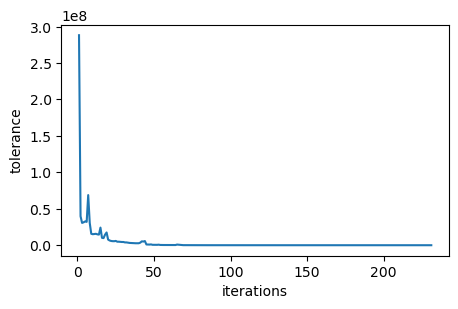

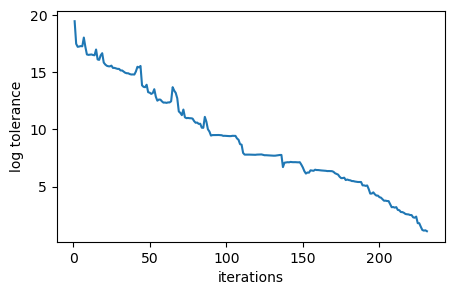

--> time = 1.53  min |  91.81 seconds
               ---> CGM converged?   True
                    ---> Fit correctly?   True
                     !!!!  Sucess..  !!!!
Building full visibility model...
F2D model in 248.04 seconds.


In [46]:
start_time = time.time()

kernel_params =  {'m': -2, 'c': 1e8, 'l': 7e4}
frank2d.fit(kernel_params = kernel_params, rtol = 1e-8 )

end_time = time.time()
print(f"F2D model in {(end_time - start_time):.2f} seconds.")

## Optimization

In [47]:
ME = MAPEstimator(frank2d._Rmax,  frank2d._Geometry)

In [48]:
frank2d.set_MAP_estimator(ME)

Setting MAP estimator...


In [49]:
frank2d.search_MAP(initial_guess={'m': -2, 'logl': 4})

Fitting the visibilities with Frank2D with 2DFT...


  + Time to set up the matrices: 847.88 seconds
Setting the initial guess...
Optimizing the posterior...


KeyboardInterrupt: 

In [ ]:
frank2d.MAP

{'m': -1.3620866384393038, 'c': 4680.764753383927, 'l': 72454.2129429396}

### Plot

In [ ]:
Plot_ = Plot(frank2d, geom)

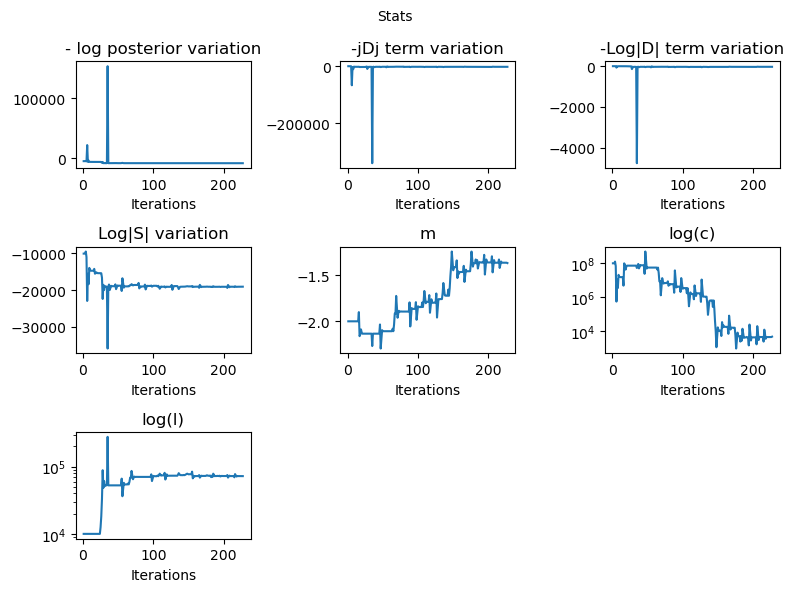

In [ ]:
Plot_.stats_optimization()

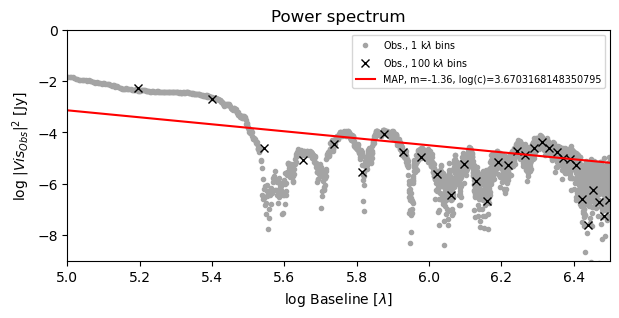

In [ ]:
Plot_.MAP_power_spectrum(uvtable)

### New Frank

In [ ]:
frank2d2 = Frank2D(N, rout, geom)

Shifted grid..
Setting gridded data...
Setting GP Kernel Wendland...
Creating sparse linear system...
--> time kernel = 0.06  min |  3.33 seconds
--> time = 0.06  min |  3.49 seconds
Solving linear system...
         * rtol: 1e-08
         * final tolerance: 2.8817519827904894
Final tolerance :  2.8817519827904894
.... iteration:  0
                        -> actual tol:  288175198.2790489 vs  2.8817519827904894
.... iteration:  1
                        -> actual tol:  26326016.46808589 vs  2.8817519827904894
.... iteration:  2
                        -> actual tol:  23214196.21818105 vs  2.8817519827904894
.... iteration:  3
                        -> actual tol:  23233565.00013925 vs  2.8817519827904894
.... iteration:  4
                        -> actual tol:  23003166.02610575 vs  2.8817519827904894
.... iteration:  5
                        -> actual tol:  22241864.859669887 vs  2.8817519827904894
.... iteration:  6
                        -> actual tol:  23847143.22388092 vs  2.

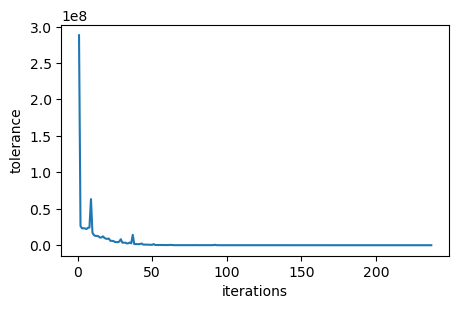

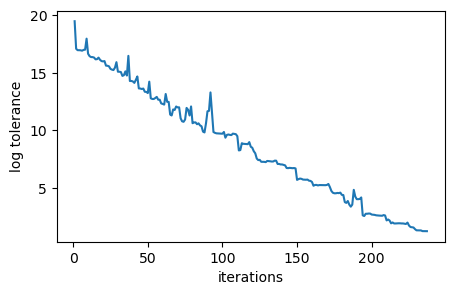

--> time = 0.17  min |  10.16 seconds
               ---> CGM converged?   True
                    ---> Fit correctly?   True
                     !!!!  Sucess..  !!!!
Building full visibility model...


In [ ]:
frank2d2.fit(data = uvtable, kernel_params = frank2d.MAP, rtol = 1e-8 )

## Plot

In [ ]:
Plot_ = Plot(frank2d2, geom)

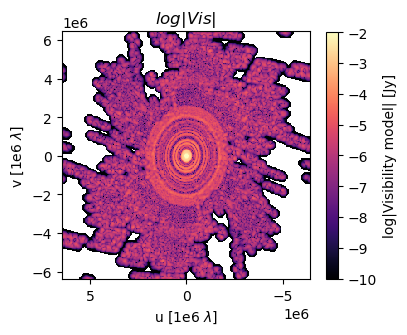

In [ ]:
Plot_.visibility(fig_size = 4)

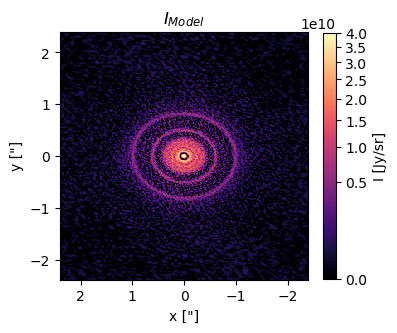

In [ ]:
Plot_.intensity(fig_size = 4)

In [ ]:
uv_table = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

Performing 1D Frank fit with alpha: 1.05 and w_smooth: 0.001...


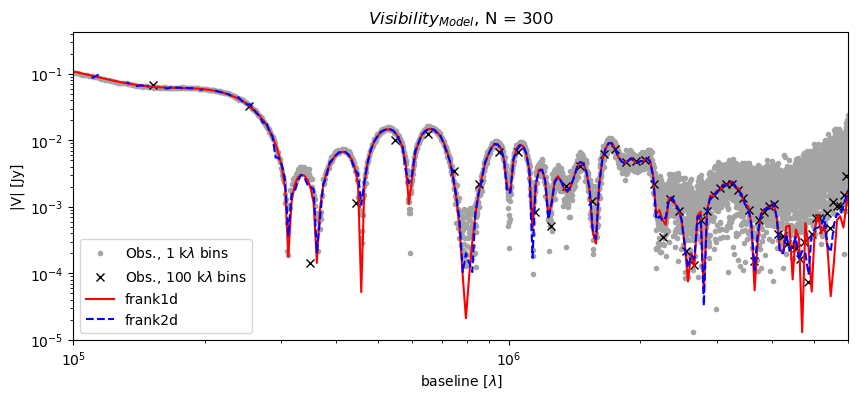

In [ ]:
Plot_.visibility_profile(input = uv_table, weighted = True, frank1d = True)